In [1]:
%pip install -q pandas numpy matplotlib scipy pyyaml ipywidgets

Note: you may need to restart the kernel to use updated packages.


# Downstream Evaluation: RankMe Geometry → Multilingual Performance

**Research question:** *Do spectral geometry features of the RankMe training trajectory predict downstream multilingual performance? Specifically: do per-language richness levels, compression dynamics, and the live geometry-performance alignment correlate with accuracy and grokking behaviour on m-MMLU, XCOPA, Belebele, and M-ARC?*

**Models:** FuxiTranyu-8B · Apertus-8B-2509  
**Benchmarks:** m-MMLU (5-shot, 8 languages) · XCOPA (0-shot, 5 languages) · Belebele (5-shot, 10 languages) · M-ARC (5-shot, 9 languages) — configured in `code/downstream_evaluation/configs/benchmarks.yaml`  
**Geometry source:** `fuxi_fine_wiki.csv` / `apertus_fine_wiki.csv`

### What this notebook does

1. **Layer selection** — reproduces the cross-language stratification analysis from `notebooks/pedro_pinto_408828.ipynb` to justify which layer's RankMe values are used throughout: layer 15 for FuxiTranyu-8B and layer 21 for Apertus-8B-2509 (layers of maximum cross-language RankMe spread).

2. **RankMe trajectory analysis** — for each language, computes key geometry metrics from the training trajectory at the selected layer: global peak, valley of first compression descent, initial drop rate, and trajectory-averaged richness. Trajectories are plotted split at the valley into a **Pre-minimum** (blue) and **Post-minimum** (green) phase, with the minimum marked.

3. **Grokking detection** — finds the first checkpoint where accuracy exceeds random chance by more than 15 percentage points and stays there for at least 2 consecutive checkpoints. Separately per task and language.

4. **Overlay plots** — dual-axis plots overlaying the RankMe trajectory and accuracy curve per language, with grokking onset marked. Split into pre/post-minimum phases. One plot per task (m-MMLU, XCOPA, Belebele, M-ARC).

5. **Predictor correlation analysis** — tests ten RankMe richness predictors (point-in-time richness, initial drop rate, trajectory-averaged means) against two outcomes (grokking onset, peak accuracy) using Spearman and Pearson correlations. Grokking onset uses only RankMe at first checkpoint (at or before grokking onset); peak accuracy uses all ten predictors. Computed separately per task, never pooled across tasks.

6. **Per-checkpoint cross-language correlation** — at every training checkpoint, computes the Spearman rank correlation between RankMe and accuracy *across languages*, yielding a trajectory that shows when and how strongly the geometry tracks the live language performance hierarchy.

In [2]:
import os
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, clear_output

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, os.path.join(REPO_ROOT, "code", "downstream_evaluation"))

from utils import (
    load_config, init_models,
    load_rankme_data, load_eval_data, load_model_data,
    compute_geometry, compute_and_show_geometry,
    compute_grokking, compute_and_show_grokking,
    compute_correlations_table, compute_and_show_correlations,
    compute_checkpoint_correlations, compute_and_show_checkpoint_correlations,
    show_stratification, layer_selection_sweep,
    plot_rankme_phases, show_rankme_phases,
    plot_predictor_scatter, show_predictor_scatter,
    plot_correlation_heatmap, show_correlation_heatmap,
    plot_checkpoint_correlations, show_checkpoint_correlations,
    show_overlay_widget,
)

warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


## Configuration

The notebook analyses **both models simultaneously**. `init_models()` loads config, colors, and benchmark metadata from `configs/benchmarks.yaml` for each model.

In [3]:
MODELS, data = init_models()

[fuxi] FuxiTranyu-8B  |  Layer: layer_15  |  Aggregation: last
[apertus] Apertus-8B-2509  |  Layer: layer_21  |  Aggregation: last


## Layer Selection

RankMe is computed at every layer and checkpoint, but the correlation and per-checkpoint analyses require choosing one representative layer per model. The layer selection analysis was performed by Pedro Pinto in `notebooks/pedro_pinto_408828.ipynb`; it is reproduced here for reading simplicity.

To select the most informative layer, we measure the **cross-language stratification signal** at each layer: for each language we average RankMe across the **first 10 training checkpoints**, then compute the standard deviation of those per-language averages across languages. Using only the first 10 checkpoints simulates the setting where a model developer selects the analysis layer early in training, before downstream evaluation results are available — 10 checkpoints corresponds to ~17% of total training for FuxiTranyu-8B (58 checkpoints) and ~22% for Apertus-8B-2509 (45 checkpoints).

**A high standard deviation means the layer separates languages strongly** — it encodes language-specific geometry rather than universal features shared by all languages. This is the layer with the most signal for predicting per-language downstream outcomes.

The stability sweep below shows which layer is selected for each value of N (number of first checkpoints used). The full stratification plot uses N=10.

In [4]:
# Layer-selection stability sweep
# For each N from 1 to the total checkpoint count, select the layer using only
# the first N checkpoints. Rows marked ← indicate a change from the previous N.
# Use this to decide how many early checkpoints are sufficient to stably
# identify the same layer as the full-checkpoint result.

for m in MODELS:
    cfg   = data[m]["cfg"]
    sweep = layer_selection_sweep(cfg["rankme_csv"])
    total = len(sweep)

    print(f"\n── {cfg['model_label']}  ({total} checkpoints total) ──────────────────")
    print(f"{'N':>4}  {'layer':>6}  {'std':>9}")
    print("-" * 26)
    for _, row in sweep.iterrows():
        marker = " ←" if not row["stable"] else ""
        print(f"{int(row['n_checkpoints']):>4}  {int(row['selected_layer']):>6}  "
              f"{row['peak_std']:>9.4f}{marker}")

    # Compact transition summary
    transitions = sweep[~sweep["stable"]].iloc[1:]   # skip row 0 (no previous)
    if transitions.empty:
        print(f"\nLayer is stable at {int(sweep['selected_layer'].iloc[0])} for all N.")
    else:
        full_layer = int(sweep["selected_layer"].iloc[-1])
        print(f"\nLayer at N=all: {full_layer}")
        print("Transitions:")
        prev_layer = int(sweep["selected_layer"].iloc[0])
        prev_n     = 1
        for _, row in transitions.iterrows():
            n = int(row["n_checkpoints"])
            print(f"  N = {prev_n} – {n - 1}: layer {prev_layer}")
            prev_layer = int(row["selected_layer"])
            prev_n     = n
        print(f"  N = {prev_n} – {total}: layer {prev_layer}")


── FuxiTranyu-8B  (58 checkpoints total) ──────────────────
   N   layer        std
--------------------------
   1      17   295.2522 ←
   2      18   293.9591 ←
   3      19   293.0230 ←
   4      19   290.9834
   5      19   288.8589
   6      20   286.3268 ←
   7      21   282.5798 ←
   8      21   282.5346
   9      21   272.7429
  10      21   270.3298
  11      21   266.5163
  12      21   261.5785
  13      21   254.1850
  14      21   246.3073
  15      21   237.1885
  16      21   226.8893
  17      21   217.9609
  18      21   210.2437
  19      17   203.3320 ←
  20      17   199.9997
  21      17   195.6135
  22      17   192.2855
  23      17   188.6972
  24      17   184.5496
  25      17   180.9716
  26      16   178.7601 ←
  27      16   177.9242
  28      16   177.5821
  29      16   176.8573
  30      16   176.1402
  31      16   175.3848
  32      16   174.6195
  33      16   173.9381
  34      16   173.0919
  35      16   172.3890
  36      16   171.6513
  37      

In [ ]:
show_stratification(MODELS, data, n_first_checkpoints=10)

### Selected layers

- **FuxiTranyu-8B → layer 21** (selected from first 10 checkpoints): peak stratification in the upper-middle region of the network when using only the first 10 checkpoints. The signal at this layer separates languages most strongly in early training.
- **Apertus-8B-2509 → layer 19** (selected from first 10 checkpoints): peak stratification just below the upper-middle region of the network in early training.

These are the layers used throughout this notebook for all correlation and per-checkpoint analyses.

## Data

Two sources are loaded:

- **`fuxi_fine_wiki.csv` / `apertus_fine_wiki.csv`** — geometry metrics for all checkpoints, all languages, and all layers. Used for layer selection, trajectory plots, and per-checkpoint correlation.

- **`fuxi_fine_wiki_mmlu_xcopa_belebele_marc_layer15_merged.csv` / `apertus_fine_wiki_mmlu_xcopa_belebele_marc_layer21_merged.csv`** — downstream accuracy for all four benchmarks merged with geometry at the selected layer. Used for grokking detection, correlation analysis, and overlay plots.

In [6]:
load_model_data(MODELS, data)

Loaded geometry data: 47,880 rows — 57 checkpoints, 14 languages
Working slice : layer_15, agg=last → 798 rows
Loaded eval: 1824 records — 4 task(s), 57 checkpoint(s)

Loaded geometry data: 39,424 rows — 44 checkpoints, 14 languages
Working slice : layer_21, agg=last → 616 rows
Loaded eval: 1408 records — 4 task(s), 44 checkpoint(s)



## RankMe Trajectories

The table below summarises key geometry metrics per language, derived from the RankMe trajectory at the working layer:

- **peak (B)** — token count at the global RankMe maximum.
- **RankMe peak** — RankMe value at the global maximum.
- **RankMe first ckpt** — representational richness at the first observed checkpoint.
- **RankMe valley** — RankMe value at the bottom of the initial compression descent.
- **valley (B)** — token count at the bottom of the initial compression descent.
- **Initial drop rate (1/B)** — (RankMe[first] − RankMe[valley]) / (valley_tokens − first_tokens).
- **RankMe last ckpt** — representational richness at the end of training.
- **mean early (0–25%)** — mean RankMe over checkpoints in the first 25% of the token range.
- **mean medium (0–50%)** — mean RankMe over checkpoints in the first 50% of the token range.
- **mean late half (50–100%)** — mean RankMe over checkpoints in the last 50% of the token range.
- **mean late (75–100%)** — mean RankMe over checkpoints in the last 25% of the token range.
- **mean before valley** — mean RankMe from the first checkpoint up to and including the valley.
- **mean after valley** — mean RankMe from the checkpoint after the valley to the last.

In [7]:
compute_and_show_geometry(MODELS, data)


── FuxiTranyu-8B ────────────────────────────────────────
  language  peak (B)  RankMe peak  RankMe first ckpt  RankMe valley  valley (B)  initial drop rate (1/B)  RankMe last ckpt  mean early (0–25%)  mean medium (0–50%)  mean late half (50–100%)  mean late (75–100%)  mean before valley  mean after valley
    Arabic      10.0     208.1951           208.1951         6.2414        94.0                 2.404211          109.5834          121.725257           117.594629                112.170314           109.692240          126.645133         112.620469
   Chinese      10.0     462.7990           462.7990         4.9610        94.0                 5.450452          210.6758          241.225943           215.600786                211.357221           215.763747          272.441522         202.379327
   English      10.0     679.2200           679.2200        12.7191        94.0                 7.934535          364.2651          444.907657           406.503457                377.606448  

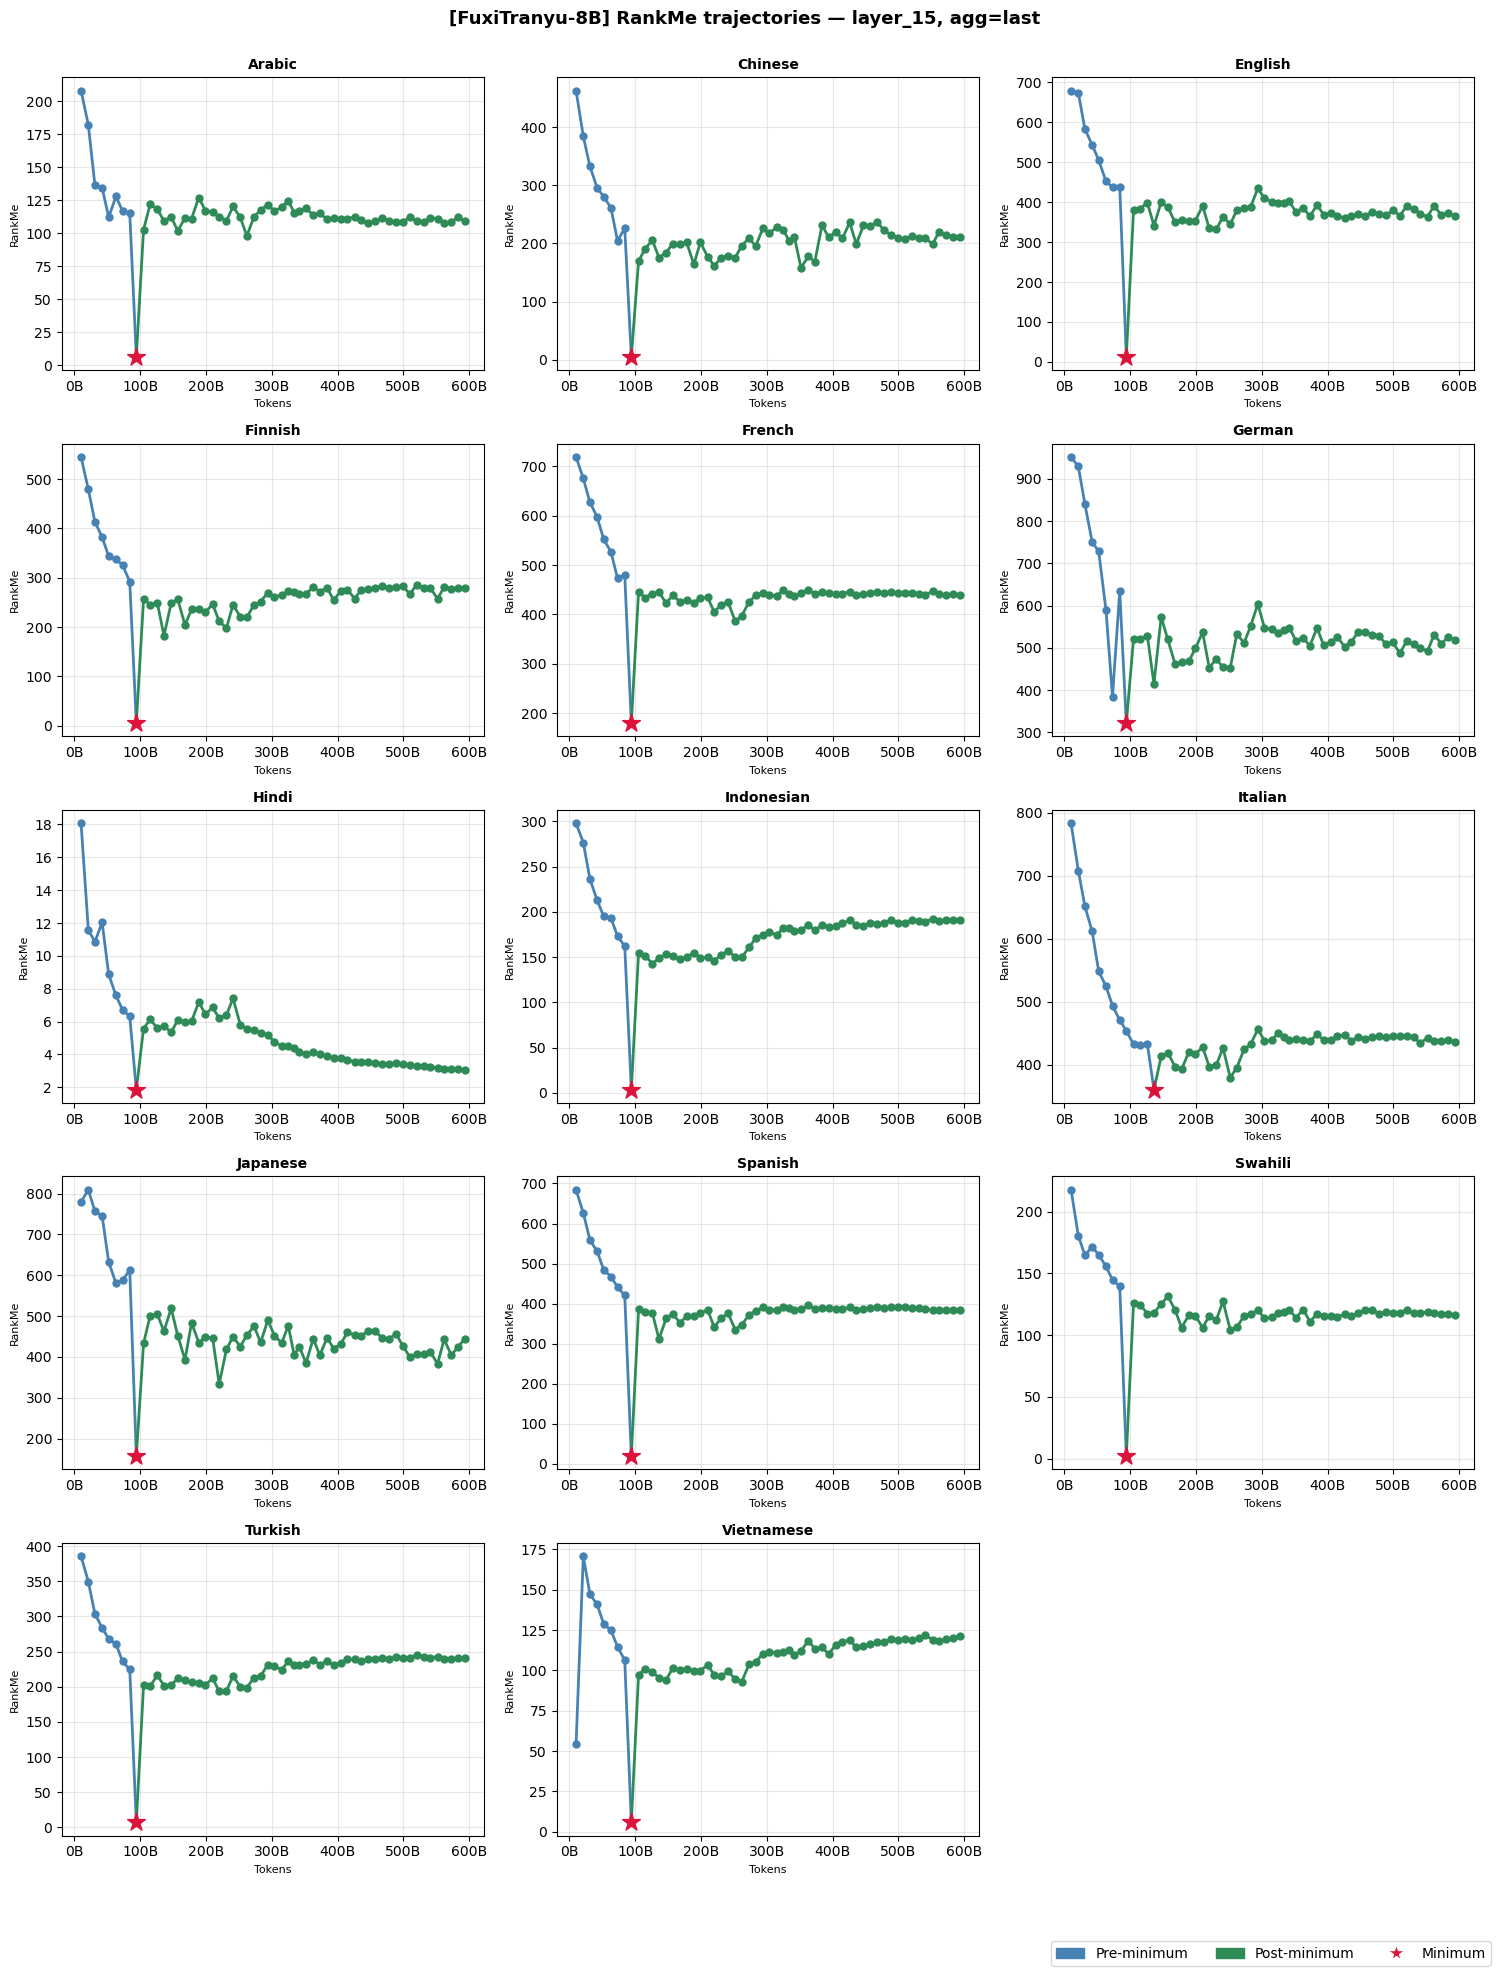

Saved: plots/rankme_phases_fuxi.png


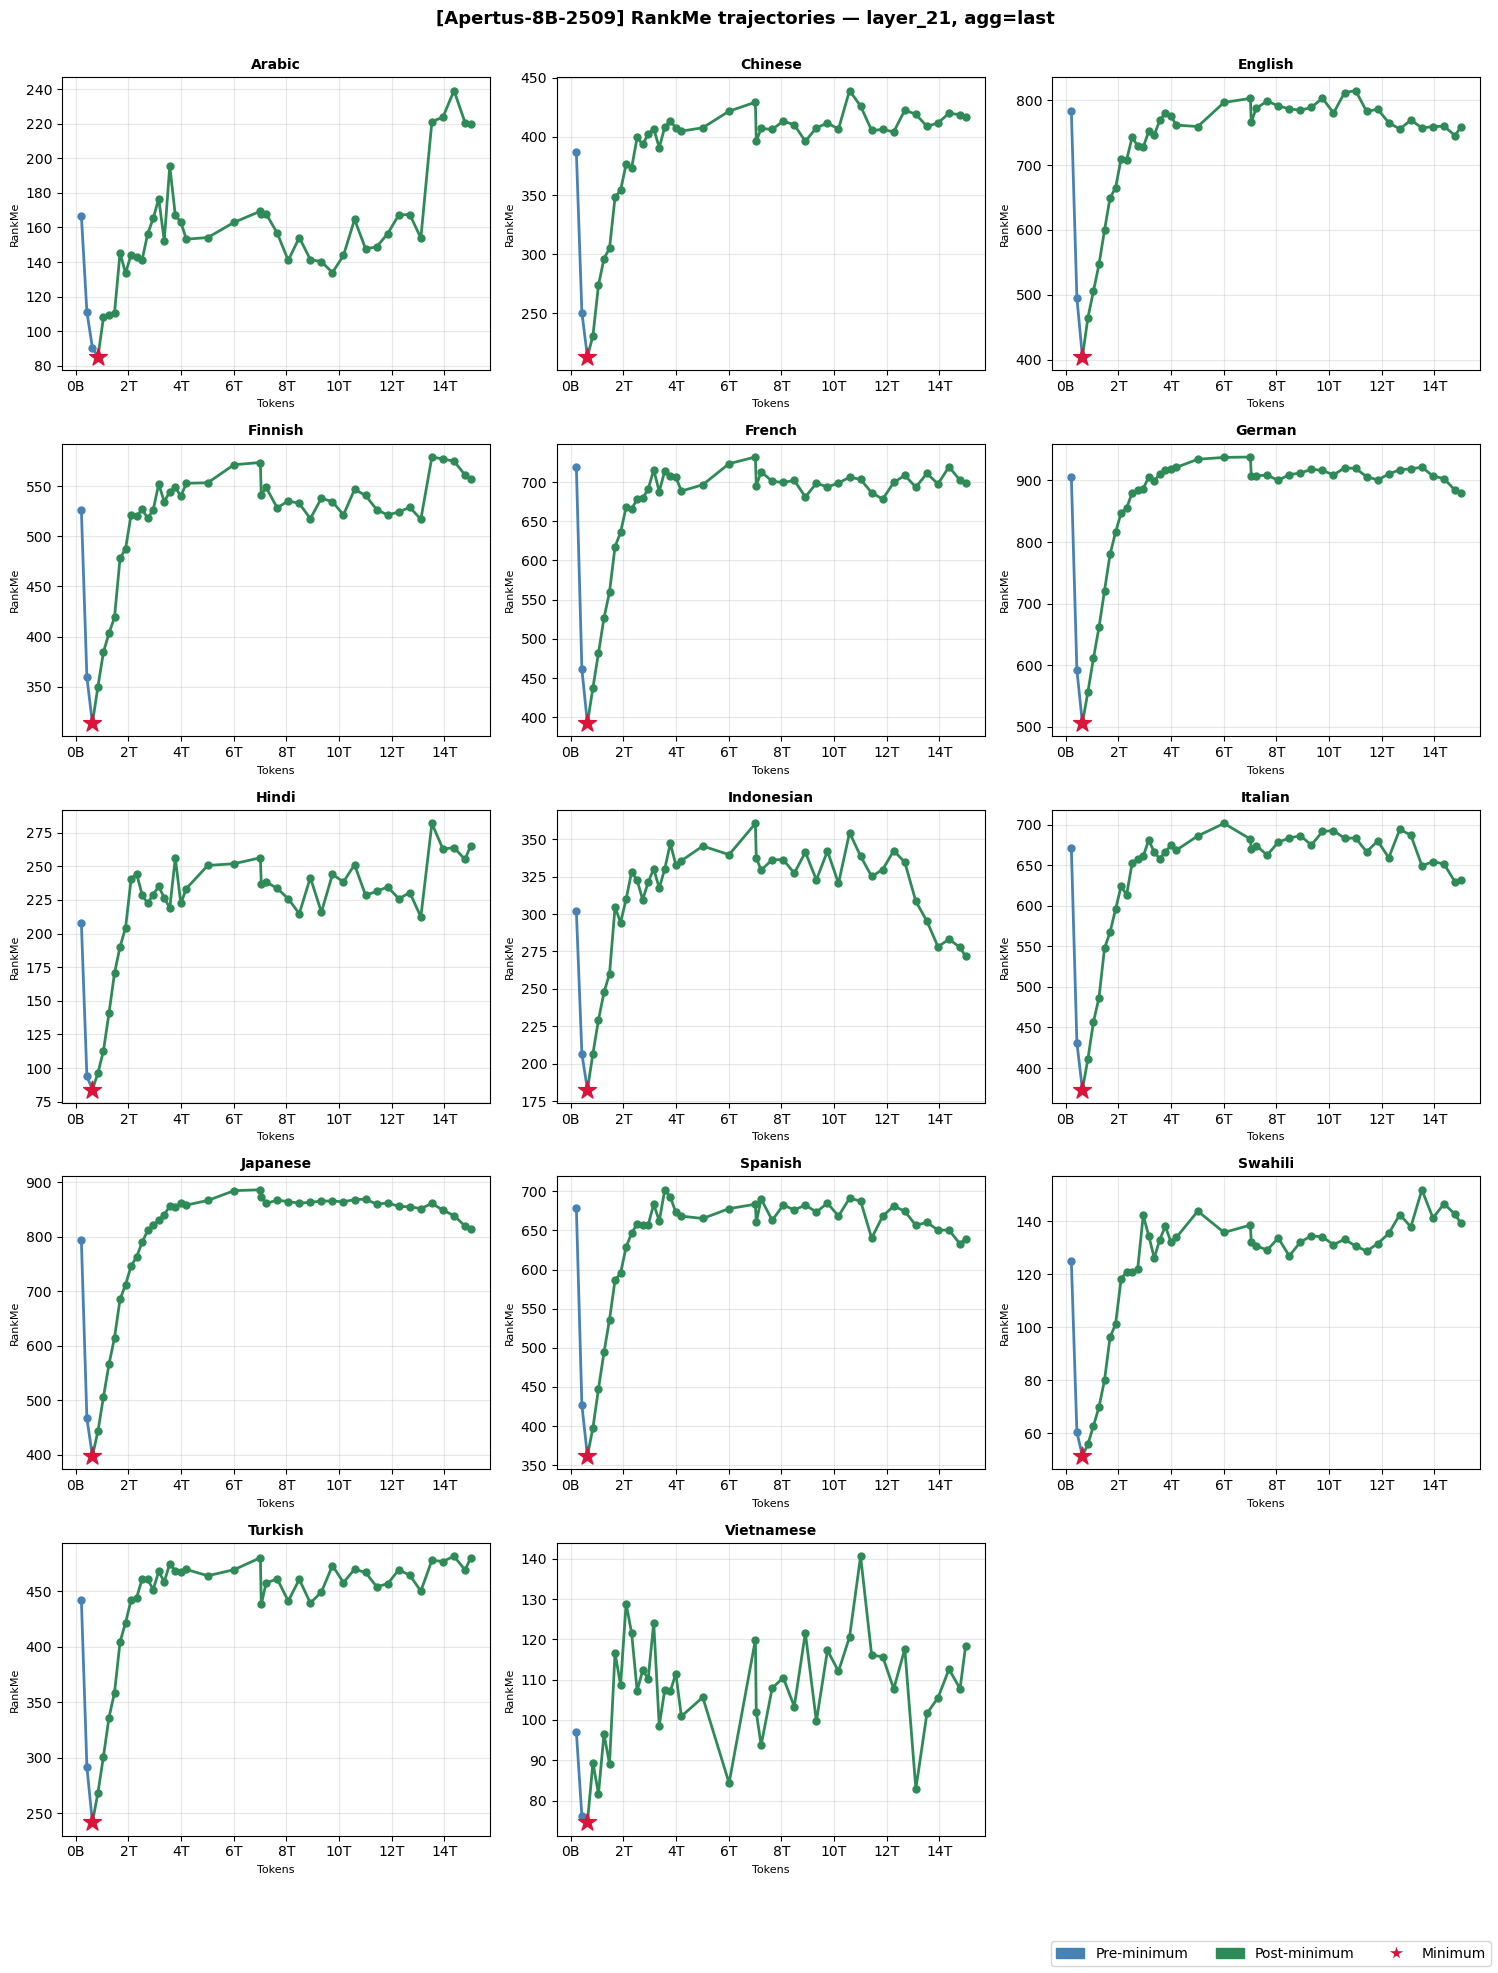

Saved: plots/rankme_phases_apertus.png


In [8]:
show_rankme_phases(MODELS, data)

## Grokking Detection

For each (task, language) pair, the table below reports when the model transitions from near-random guessing to genuinely solving the task. Grokking onset and peak accuracy serve as the outcome variables for the RankMe correlation analysis.

- **grokking_tokens (B)** — token count (in billions) at the first checkpoint where accuracy exceeds random chance by more than 15 percentage points and stays there for at least 2 consecutive checkpoints.
- **peak_tokens (B)** — token count at the checkpoint with the highest observed accuracy.
- **peak_accuracy** — highest accuracy seen across all checkpoints.
- **random_chance** — baseline accuracy for a random classifier (0.25 for 4-way m-MMLU, Belebele, and M-ARC; 0.50 for 2-way XCOPA).

A `NaN` grokking onset means one of two things: either the model never exceeded the threshold at any checkpoint (accuracy stays near random chance throughout), or the threshold was crossed only once without the required 2 consecutive checkpoints.

In [9]:
compute_and_show_grokking(MODELS, data)


── FuxiTranyu-8B ────────────────────────────────────────
    task   language  grokking onset (B)  peak (B)  peak accuracy  random chance
  m_mmlu    English                 NaN     115.0       0.272590           0.25
  m_mmlu    Chinese                 NaN     334.0       0.272921           0.25
  m_mmlu     German                 NaN     199.0       0.274928           0.25
  m_mmlu    Spanish                 NaN     241.0       0.276211           0.25
  m_mmlu    Italian                 NaN     415.0       0.275818           0.25
  m_mmlu     Arabic                 NaN     531.0       0.273824           0.25
  m_mmlu      Hindi                 NaN     210.0       0.269438           0.25
  m_mmlu Indonesian                 NaN     115.0       0.273033           0.25
   xcopa    Chinese               325.0     426.0       0.664000           0.50
   xcopa    Italian               241.0     520.0       0.718000           0.50
   xcopa Vietnamese               126.0     436.0       0.736

## Overlay Plots

One plot per selected task, with one panel per language. Each panel shows two y-axes:

- **Left axis** — RankMe trajectory split into two phases: **blue** = Pre-minimum, **green** = Post-minimum. A red star marks the minimum point.
- **Right axis (red, dashed)** — downstream accuracy across all checkpoints. The axis always spans 0 to 1.

The black dashed horizontal line marks the random-chance baseline (0.25 for m-MMLU / Belebele / M-ARC, 0.50 for XCOPA). A vertical purple dashed line marks the grokking onset for that language — absent when grokking was not detected.

> **Note:** M-MMLU is selected by default for reading purposes. Use the checkboxes to choose any combination of tasks (M-MMLU, XCOPA, Belebele, M-ARC) per model, then click **Generate plots** to update. Rendering takes approximately 2 seconds per task per model.

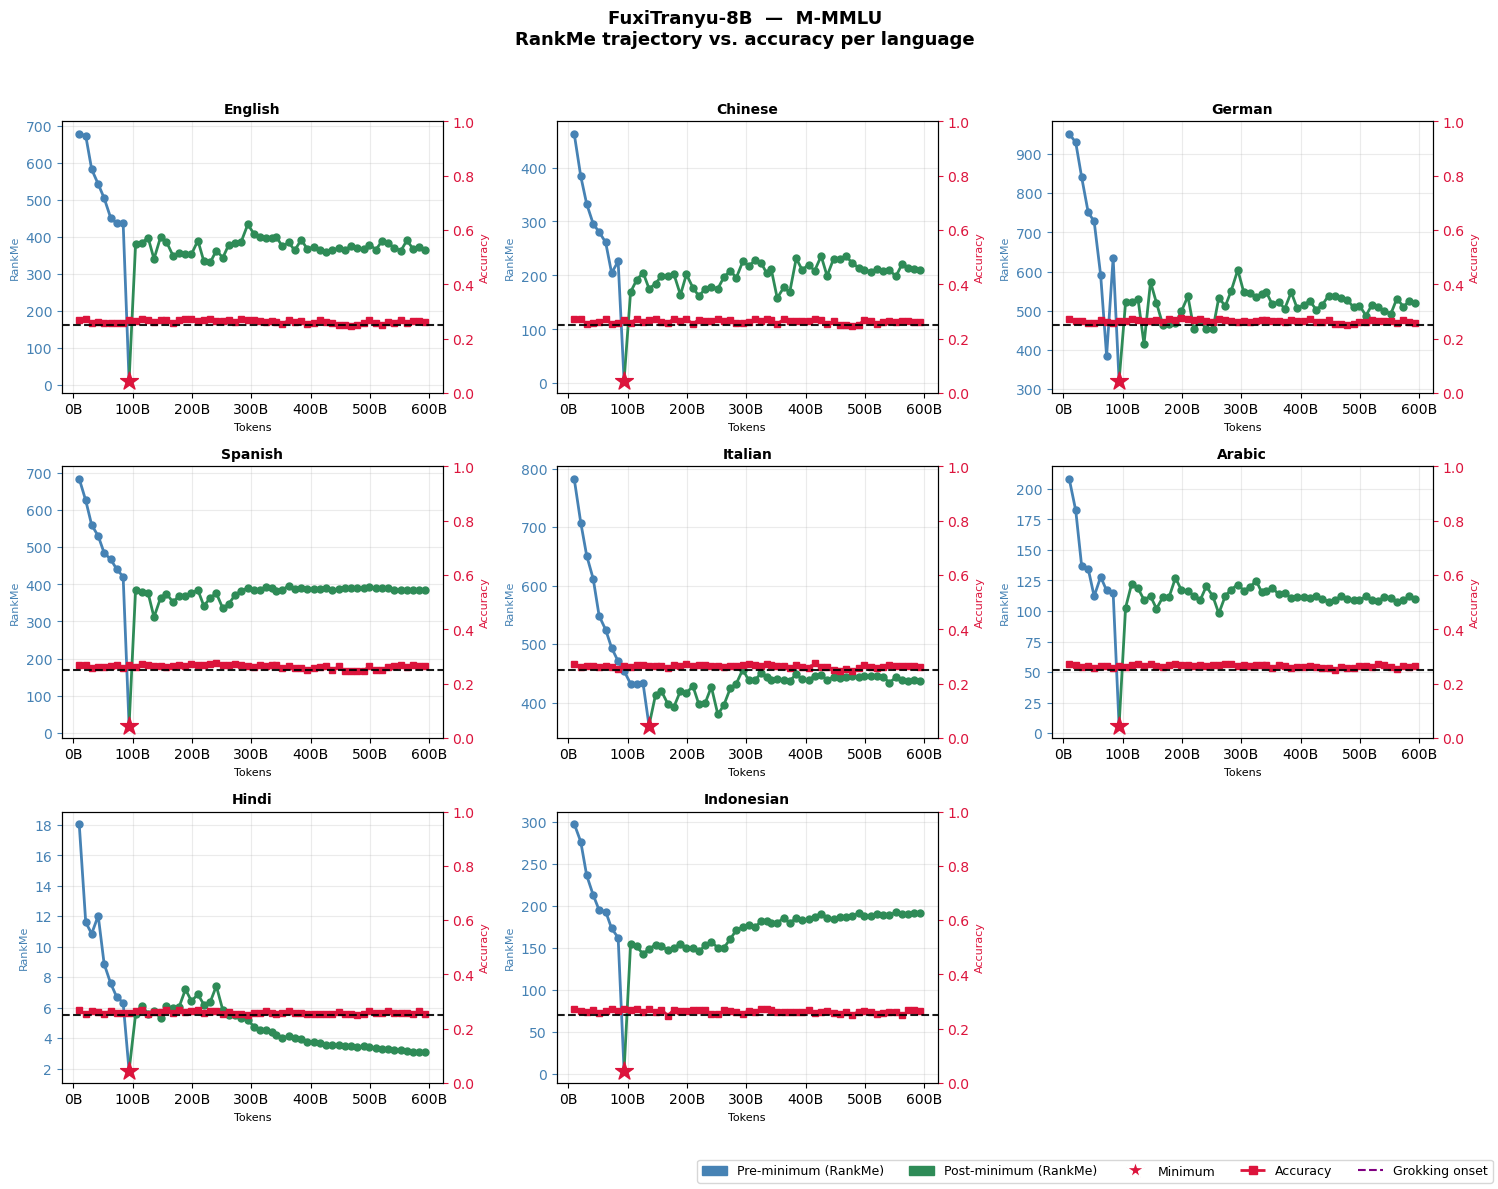

Saved: plots/overlay_m_mmlu_fuxi.png


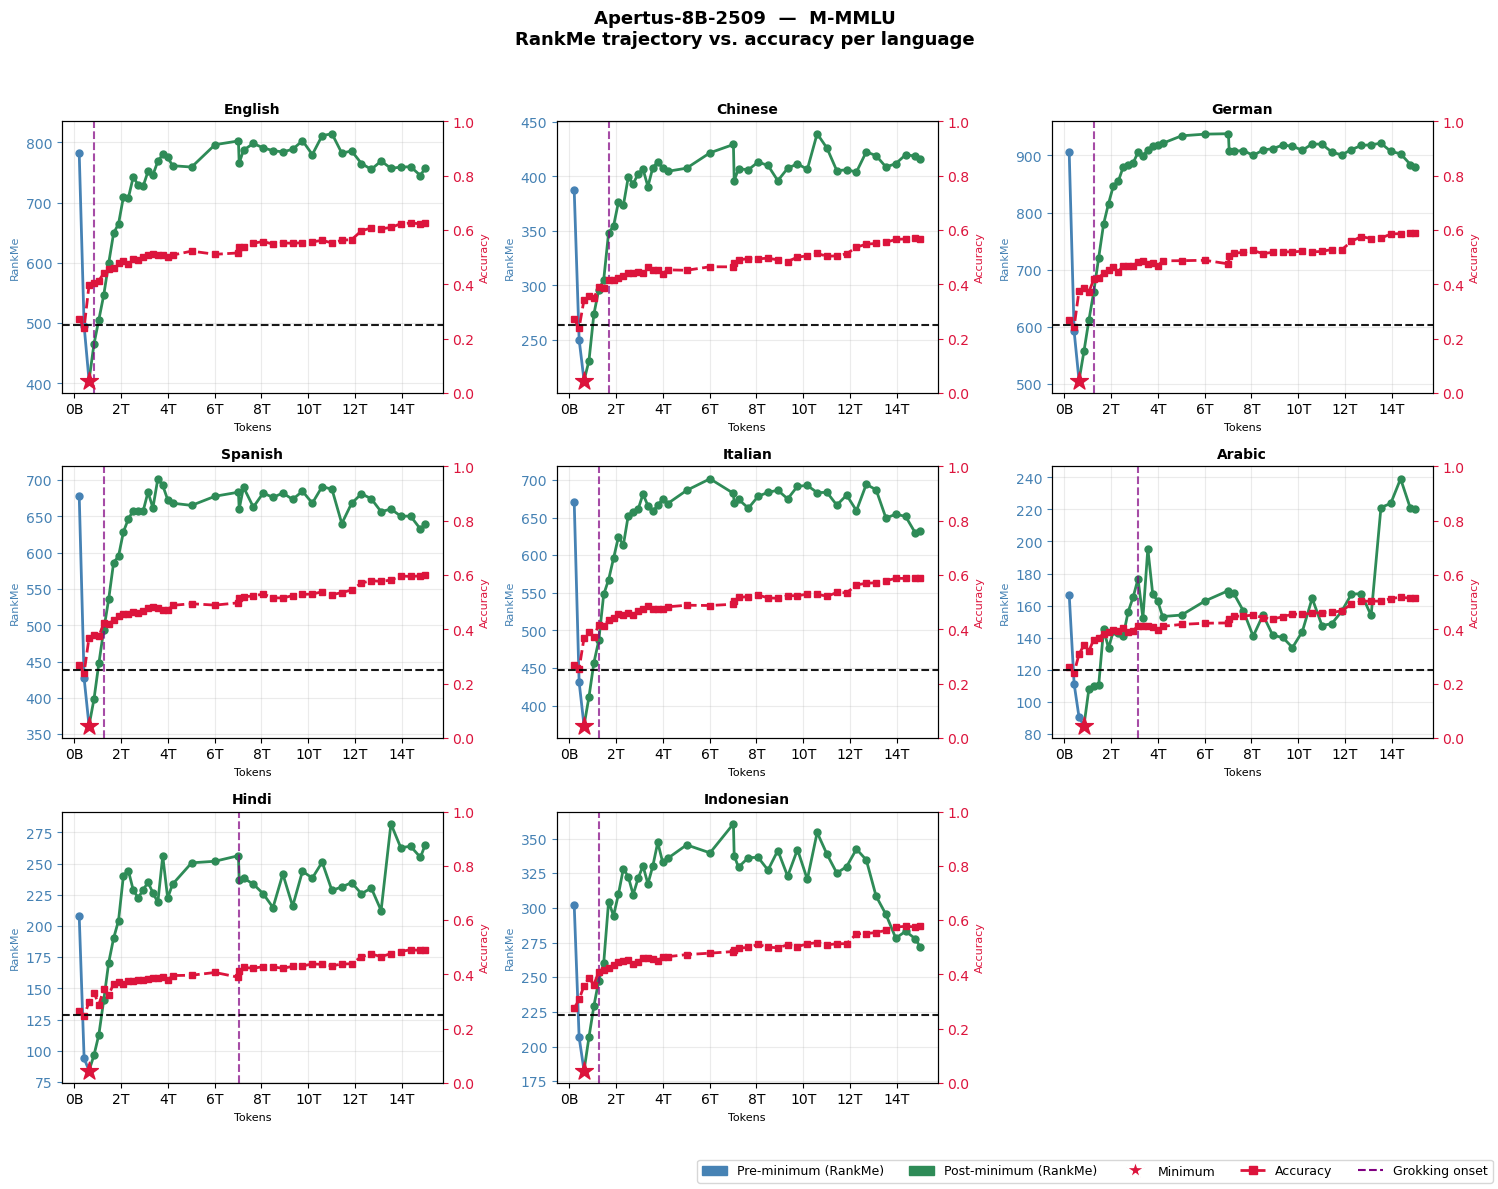

Saved: plots/overlay_m_mmlu_apertus.png


In [10]:
show_overlay_widget(MODELS, data)

## Geometry–Performance Correlation: Do RankMe trajectory features predict grokking onset and peak accuracy?

Tests whether RankMe geometry predicts downstream performance. The predictor set depends on the outcome:

**Grokking onset** uses only **RankMe at first ckpt** — the single checkpoint at or before grokking onset in every (model, task, language) combination. No other predictor adds statistically significant signal for this outcome beyond it, and using later trajectory data would risk incorporating post-grokking information.

**Peak accuracy** uses all **ten richness predictors** (retrospective — no leakage risk):
- **RankMe at first ckpt** — representation richness at the start of training.
- **RankMe at valley** — representation richness at the bottom of the initial compression descent.
- **Initial RankMe drop rate (1/B)** — (RankMe[first] − RankMe[valley]) / (tokens[valley] − tokens[first]); how steeply the model compresses each language's representations during the initial descent.
- **RankMe at last ckpt** — representation richness at the end of training.
- **Mean RankMe — first 25% of tokens** — average over checkpoints in the first quarter of the token range.
- **Mean RankMe — first 50% of tokens** — average over checkpoints in the first half of the token range.
- **Mean RankMe — last 50% of tokens** — average over checkpoints in the last half of the token range.
- **Mean RankMe — last 25% of tokens** — average over checkpoints in the last quarter of the token range.
- **Mean RankMe — before valley** — average over all checkpoints from start up to and including the valley.
- **Mean RankMe — after valley** — average over all checkpoints after the valley to the end of training.

Both Spearman (rank-based) and Pearson (linear) correlations are reported, computed separately per task and never pooled.

In [11]:
compute_and_show_correlations(MODELS, data)


── FuxiTranyu-8B ────────────────────────────────────────
    task                     predictor (x)        outcome (y)  n_languages  spearman_r  spearman_p  pearson_r  pearson_p
  m_mmlu              RankMe at first ckpt Grokking onset (B)            0         NaN         NaN        NaN        NaN
  m_mmlu              RankMe at first ckpt      Peak accuracy            8      0.6667      0.0710     0.7497     0.0322
  m_mmlu                  RankMe at valley      Peak accuracy            8      0.7619      0.0280     0.5376     0.1694
  m_mmlu    Initial RankMe drop rate (1/B)      Peak accuracy            8      0.2143      0.6103     0.5573     0.1512
  m_mmlu               RankMe at last ckpt      Peak accuracy            8      0.6667      0.0710     0.7731     0.0244
  m_mmlu Mean RankMe — first 25% of tokens      Peak accuracy            8      0.5238      0.1827     0.7403     0.0357
  m_mmlu Mean RankMe — first 50% of tokens      Peak accuracy            8      0.5238      0.

### Correlation Heatmap

The table above has rows for each (task × outcome × predictor) combination. The heatmap below condenses all of them into a single 10×8 figure per model (rows = all 10 richness predictors, columns = tasks × outcomes). Colour encodes Spearman ρ; * marks p < 0.05. Gray cells indicate undefined correlations (zero variance in the predictor) or predictors not used for that outcome — the 9 non-first-checkpoint predictor rows are gray in all grokking onset columns.

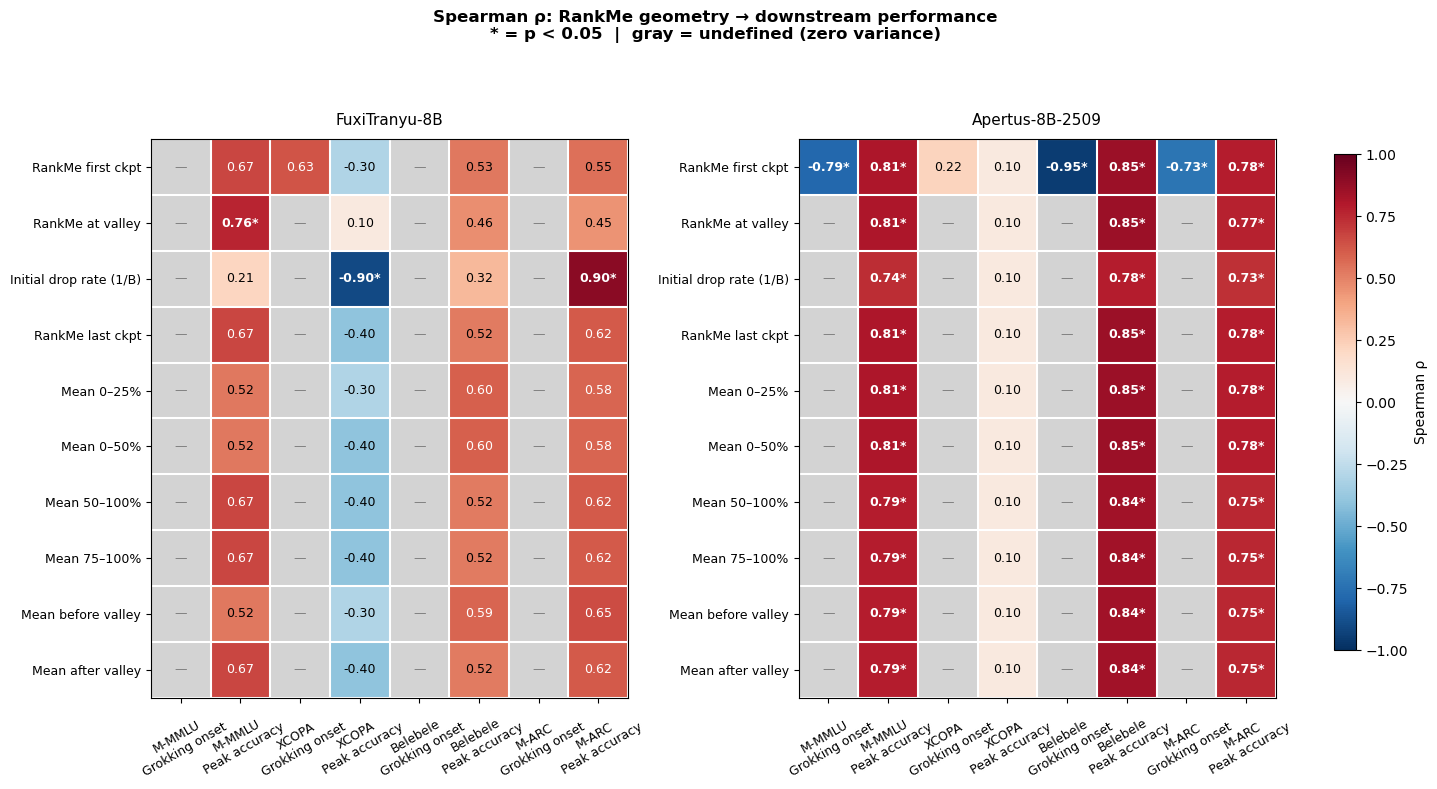

Saved: plots/correlation_heatmap.png


In [12]:
show_correlation_heatmap(MODELS, data)

### Selected Scatter Plot

**RankMe at first checkpoint** is highlighted as the single most interpretable predictor: it requires only one forward pass at the very first checkpoint — no valley detection, no trajectory averaging — yet it is the only predictor used for grokking onset and among the strongest for peak accuracy across all tasks for Apertus. The figure shows one row per task (m-MMLU, XCOPA, Belebele, M-ARC) against both outcomes, with per-model regression lines and Spearman/Pearson statistics.

> **What to look for:** For Apertus, a consistent pattern is visible for m-MMLU, Belebele, and M-ARC — richer representations at the first checkpoint correlate with earlier grokking onset and higher peak accuracy. XCOPA is the exception: all 5 languages score between 0.702 and 0.784, so outcomes are too tightly clustered for representational richness to differentiate them. For Fuxi, m-MMLU and Belebele stay at random chance throughout training, leaving no signal. Only M-ARC shows a meaningful correlation (Pearson r = +0.786, p = 0.012). For XCOPA the initial drop rate is the informative predictor — not RankMe at first checkpoint.

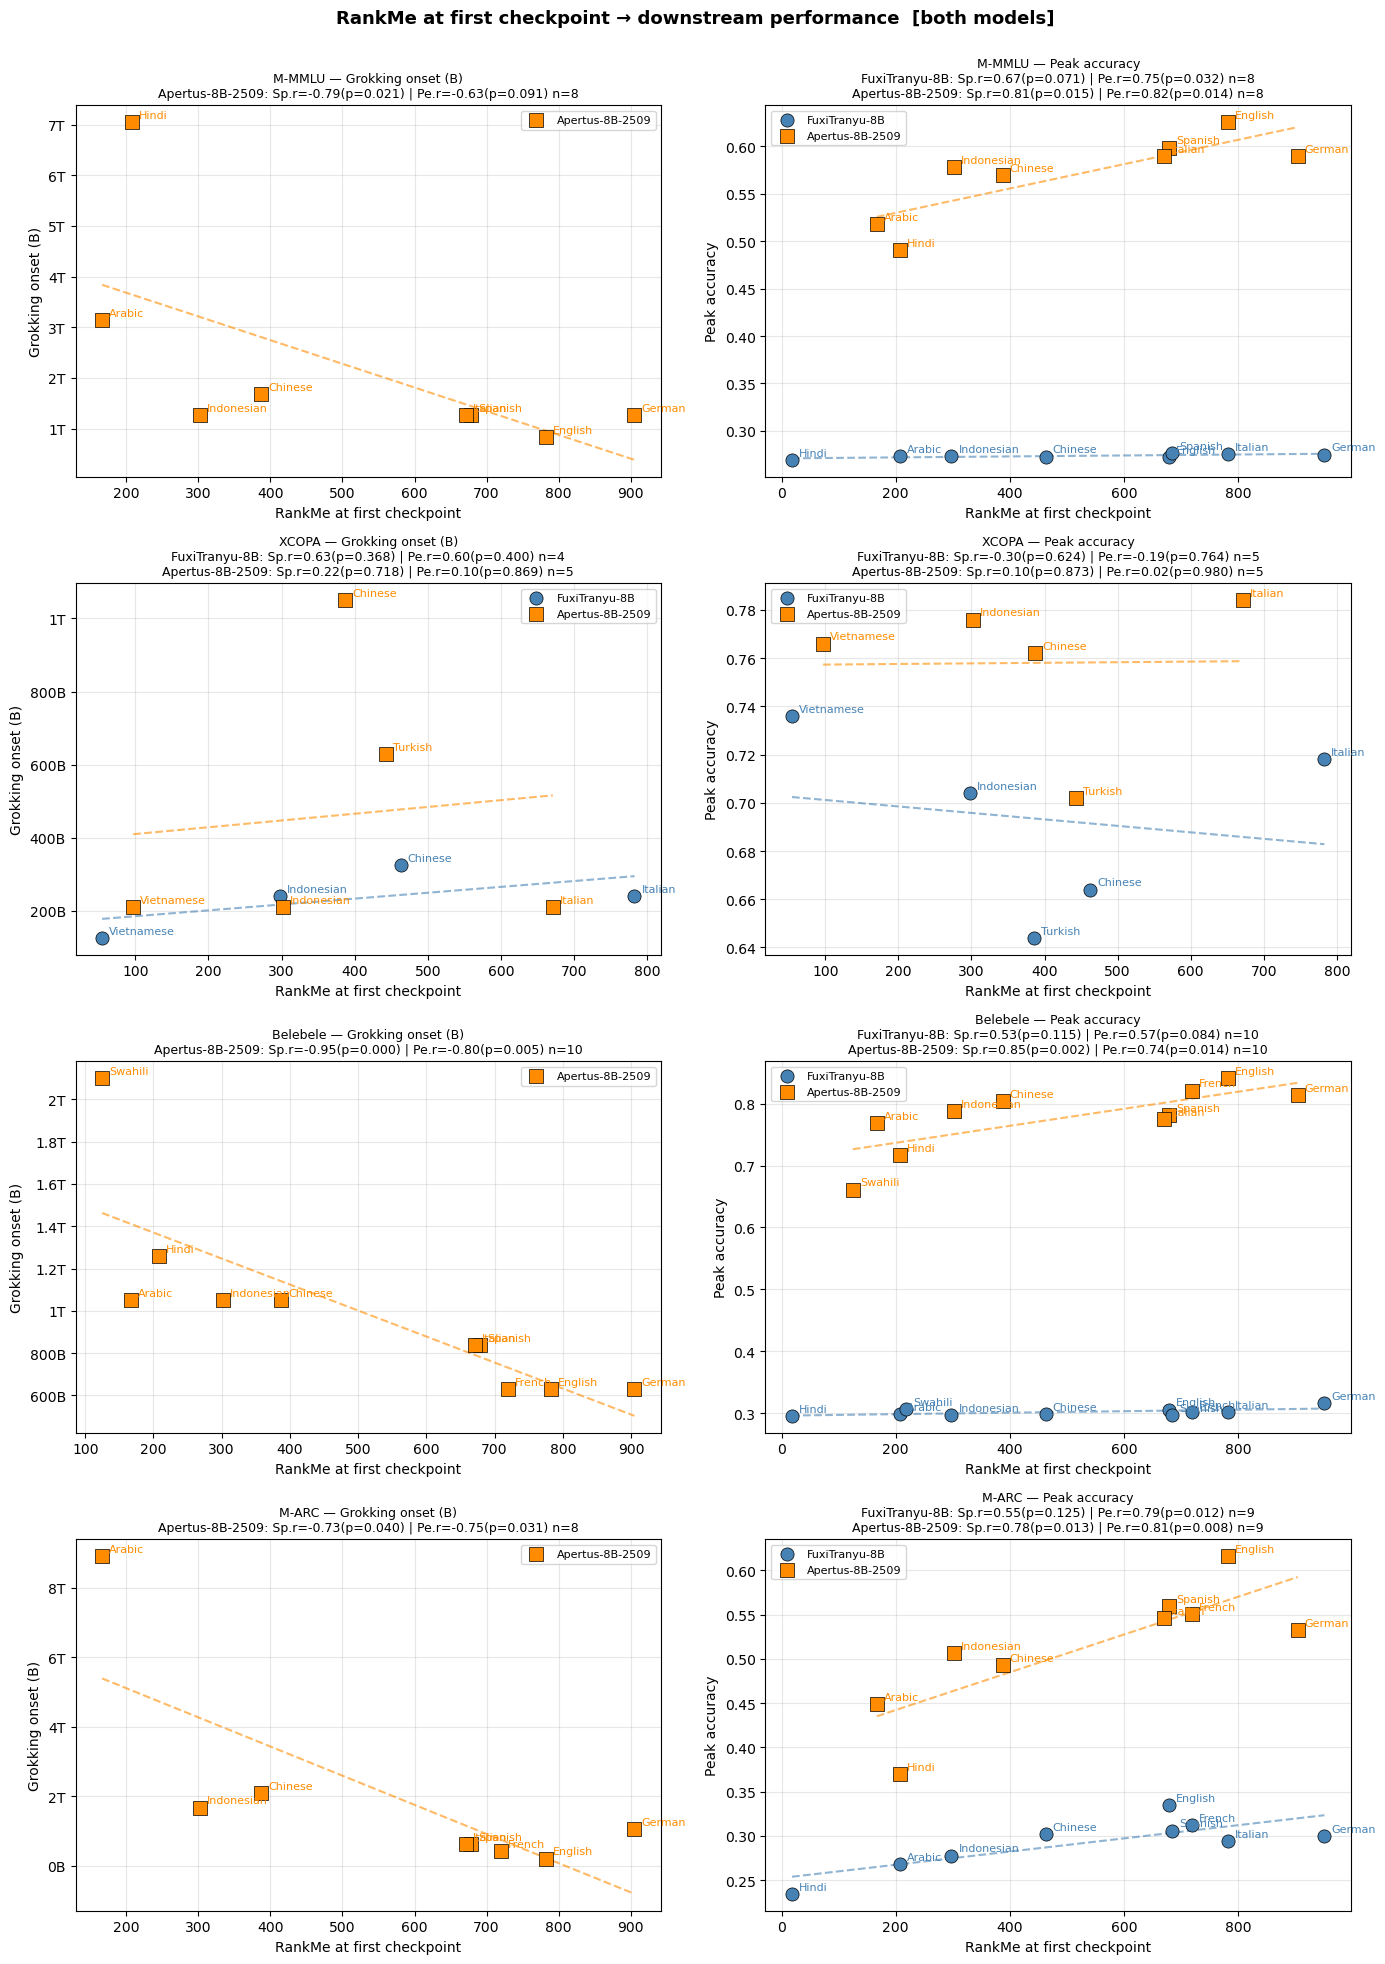

Saved: plots/scatter_rankme_first.png


In [13]:
show_predictor_scatter(MODELS, data, "rankme_first", "RankMe at first checkpoint")

## Predictor Analysis Findings

### FuxiTranyu-8B

**Phase structure** — Layer 15 (std = 160.9): peak RankMe spans nearly two orders of magnitude, from German (952) and Japanese (809) down to Hindi (18) and Vietnamese (171). 12 of 14 languages peak at 10B tokens; Japanese and Vietnamese at 21B. All languages reach their valley at 94B (136B for Italian).

**m-MMLU** — Accuracy stays at random chance (~25%) across all 57 checkpoints for all 8 languages. No grokking detected. Apparent correlations with peak accuracy are spurious: the accuracy range is only 0.007, entirely within sampling noise.

**XCOPA** — 4 of 5 languages grokked: Vietnamese (126B), Italian and Indonesian (241B), Chinese (325B); Turkish never crossed the threshold. Grokking onset (rankme_first only, n=4): Sp r = +0.633, p = 0.368 — not significant; with n=4 the minimum exact two-tailed Spearman p-value is ≈ 0.083, so significance is structurally impossible. **Initial drop rate is the only significant predictor of peak accuracy: Sp r = −0.900, p = 0.037** — languages that compress more steeply achieve lower XCOPA accuracy. The ordering is exact: Vietnamese (lowest drop rate, 0.58/B) → best performance; Chinese (5.45/B) → second-worst; Turkish (4.51/B, no grokking). All other predictors are not significant (all p > 0.37).

**Belebele** — All 10 languages stay near random chance (peak accuracy 0.296–0.317). No grokking detected. No significant predictors; accuracy range (~0.02) is too narrow for reliable inference.

**M-ARC** — No grokking; peak accuracy spans 0.235 (Hindi) to 0.335 (English). **Initial drop rate → peak accuracy: Sp r = +0.900, p = 0.0009** — the strongest geometry–performance correlation for Fuxi across all benchmarks. RankMe at first checkpoint reaches significance by Pearson only (Pe r = +0.786, p = 0.012; Sp r = +0.550, p = 0.125). The sign is positive — opposite to XCOPA: languages with steeper compression achieve *higher* M-ARC accuracy.

---

### Apertus-8B-2509

**Phase structure** — Layer 21 (std = 248.4): peak RankMe ranges from German (938) and Japanese (886) down to Swahili (152) and Vietnamese (141). All languages valley at 630B (Arabic: 840B); the global peak occurs late in training (3 570B–14 372B depending on language).

**m-MMLU** — All 8 languages grokked (840B–7 047B). Grokking onset (rankme_first only): **Sp r = −0.786, p = 0.021** — richer representations at the first checkpoint → earlier grokking. Pearson is not significant (p = 0.091), indicating a rank-monotone but non-linear relationship. Peak accuracy: **all 10 richness predictors are significant (Sp r = +0.738–0.810, all p < 0.037)**.

**XCOPA** — All 5 languages grokked (210B–1 050B). Grokking onset (rankme_first): Sp r = +0.224, p = 0.718 — not significant. Peak accuracy: **no predictor is significant** (all p > 0.87). XCOPA outcomes are too tightly clustered (0.702–0.784) for representational richness to differentiate languages.

**Belebele** — All 10 languages grokked (630B–2 100B). **Strongest geometry–performance relationship in the analysis:** grokking onset (rankme_first): **Sp r = −0.947, p < 0.001**; peak accuracy: **Sp r = +0.855, p = 0.0016** for RankMe at first ckpt — languages with richer representations at the very first checkpoint achieve higher reading comprehension accuracy, replicating the m-MMLU pattern. The initial drop rate is also significant for peak accuracy (Sp r = +0.782, p = 0.0075).

**M-ARC** — 8 of 9 languages grokked (210B–8 912B; Hindi did not). Grokking onset (rankme_first): **Sp r = −0.731, p = 0.040** — significant by both Spearman and Pearson. Peak accuracy: **all 10 richness predictors significant (Sp r = +0.733–0.783, all p < 0.025)** — RankMe at first checkpoint again predicts which languages achieve higher science reasoning accuracy (Sp r = +0.783, p = 0.013), consistent with m-MMLU and Belebele.

---

### Cross-model summary

**The only finding that replicates across both models with the same direction is: initial RankMe drop rate → M-ARC peak accuracy.**
- FuxiTranyu-8B: Sp r = +0.900, p = 0.0009
- Apertus-8B-2509: Sp r = +0.733, p = 0.025

All other cross-model comparisons fail because Fuxi never learns most benchmarks during pre-training: m-MMLU and Belebele accuracy stays at random chance (no variance, no valid correlations), and XCOPA grokking onset has only n=4 events (underpowered). The richness-predictor findings for Apertus (m-MMLU, Belebele, M-ARC) have no Fuxi counterpart — except M-ARC.

---
### 💡Key findings 

- **Apertus — m-MMLU, Belebele, M-ARC:** RankMe at first checkpoint is negatively correlated with grokking onset (richer → earlier grokking) and positively correlated with peak accuracy (richer → higher accuracy).
- **Apertus — XCOPA:** no predictor reaches significance for any outcome — XCOPA outcomes are too tightly clustered for representational richness to differentiate languages.
- **Fuxi — XCOPA:** initial drop rate is the only significant predictor of peak accuracy (**Sp r = −0.900**, negative) — languages that compress more steeply perform *worse* on XCOPA. ⚠️ This is the opposite of what the initial drop rate predicts everywhere else (M-ARC in both models, and m-MMLU and Belebele in Apertus), showing that XCOPA does not follow the same compression dynamics as the other benchmarks.
- **Both models — M-ARC:** initial drop rate positively predicts peak accuracy — languages with steeper early compression achieve higher science reasoning accuracy.

## Per-Checkpoint Correlation: Does geometry track the language performance hierarchy over training?

The previous predictor analysis tested whether a single geometry metric (computed from the full RankMe trajectory) predicts a language's final downstream outcome. Here we ask a complementary question: **at each training checkpoint, does the cross-language ranking of RankMe match the cross-language ranking of accuracy at that same checkpoint?**

At any given checkpoint (say, 3 990B tokens), we have two values per language — RankMe and accuracy on a given task — and we compute **one Spearman correlation** across all languages. For example, for Apertus at 3 990B on m-MMLU, sorted by RankMe:

| Language   | RankMe @ 3 990B | m-MMLU accuracy @ 3 990B |
|------------|:--------------:|:------------------------:|
| English    | 1251.7         | 0.500                    |
| German     | 1081.5         | 0.467                    |
| Italian    | 1028.8         | 0.474                    |
| Chinese    |  874.6         | 0.439                    |
| Spanish    |  866.0         | 0.472                    |
| Indonesian |  863.4         | 0.463                    |
| Arabic     |  571.3         | 0.396                    |
| Hindi      |  537.5         | 0.378                    |

The language ranking by RankMe broadly tracks the accuracy ranking — languages with richer representations tend to have higher accuracy at this checkpoint. Repeating this at every checkpoint produces a curve that answers: **as training progresses, does the model's geometry become a better or worse predictor of which languages it handles best?**

- A **positive ρ** means languages with higher RankMe also have higher accuracy at that moment.
- A **near-zero ρ** means the two rankings are unrelated — the geometry has no predictive power at that checkpoint.
- **Filled markers** = p < 0.05 (statistically significant); **open markers** = p ≥ 0.05.

In [14]:
compute_and_show_checkpoint_correlations(MODELS, data)


── FuxiTranyu-8B ────────────────────────────────────────
  m_mmlu: 3/57 checkpoints with p<0.05 | max ρ = 0.762 | min ρ = -0.524
  xcopa: 1/57 checkpoints with p<0.05 | max ρ = 0.100 | min ρ = -0.900
  belebele: 5/57 checkpoints with p<0.05 | max ρ = 0.869 | min ρ = -0.746
  m_arc: 18/57 checkpoints with p<0.05 | max ρ = 0.803 | min ρ = -0.367

── Apertus-8B-2509 ────────────────────────────────────────
  m_mmlu: 40/44 checkpoints with p<0.05 | max ρ = 0.952 | min ρ = 0.048
  xcopa: 0/44 checkpoints with p<0.05 | max ρ = 0.200 | min ρ = -0.700
  belebele: 42/44 checkpoints with p<0.05 | max ρ = 0.967 | min ρ = 0.189
  m_arc: 44/44 checkpoints with p<0.05 | max ρ = 0.900 | min ρ = 0.683


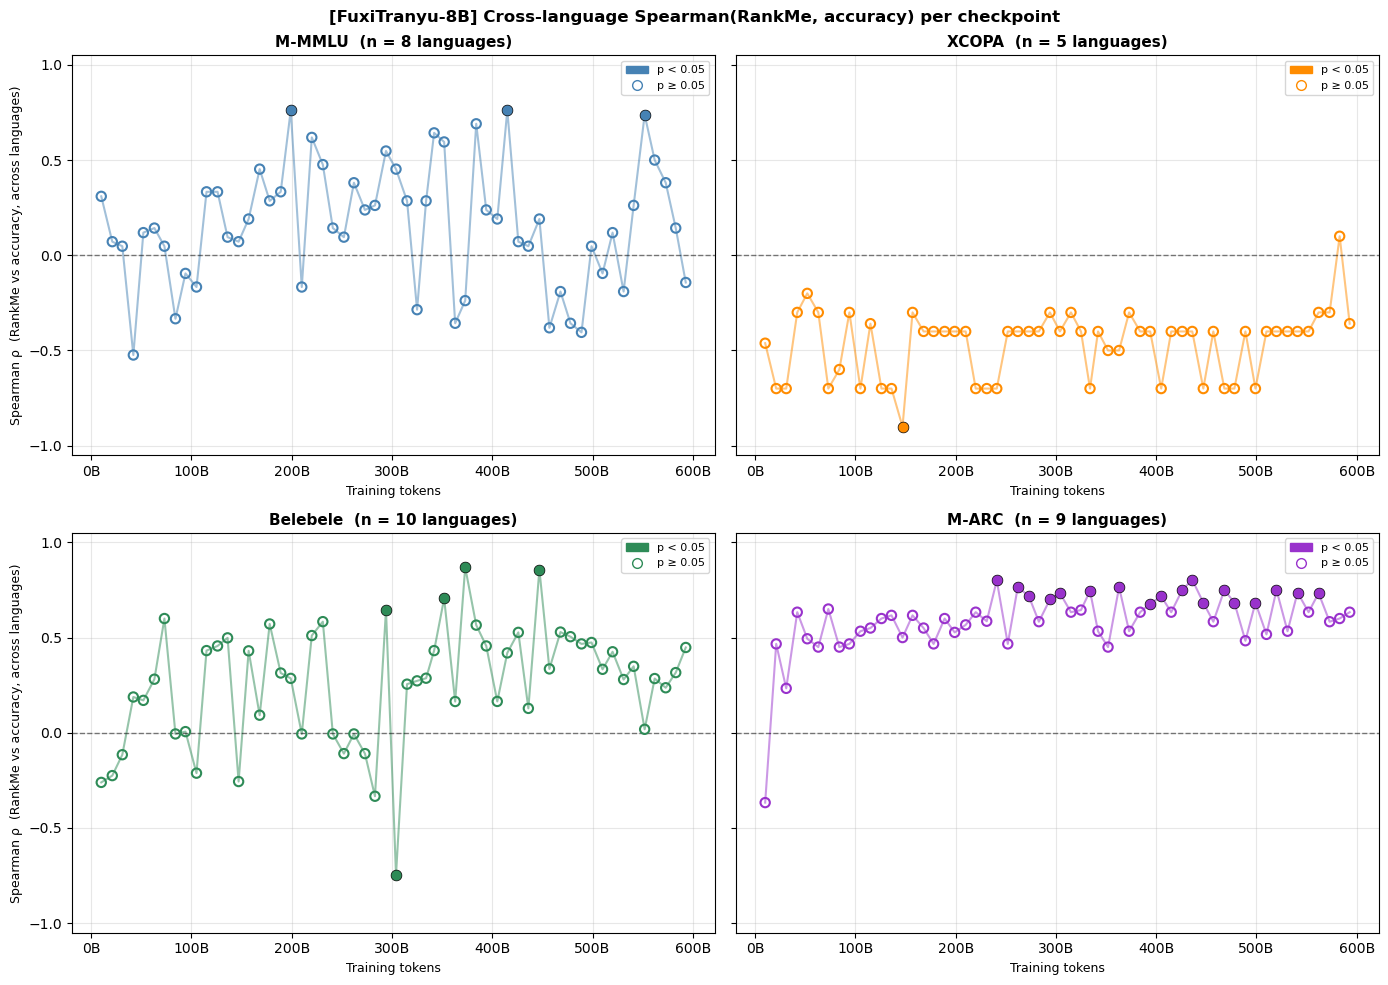

Saved: plots/rankme_checkpoint_correlations_fuxi.png


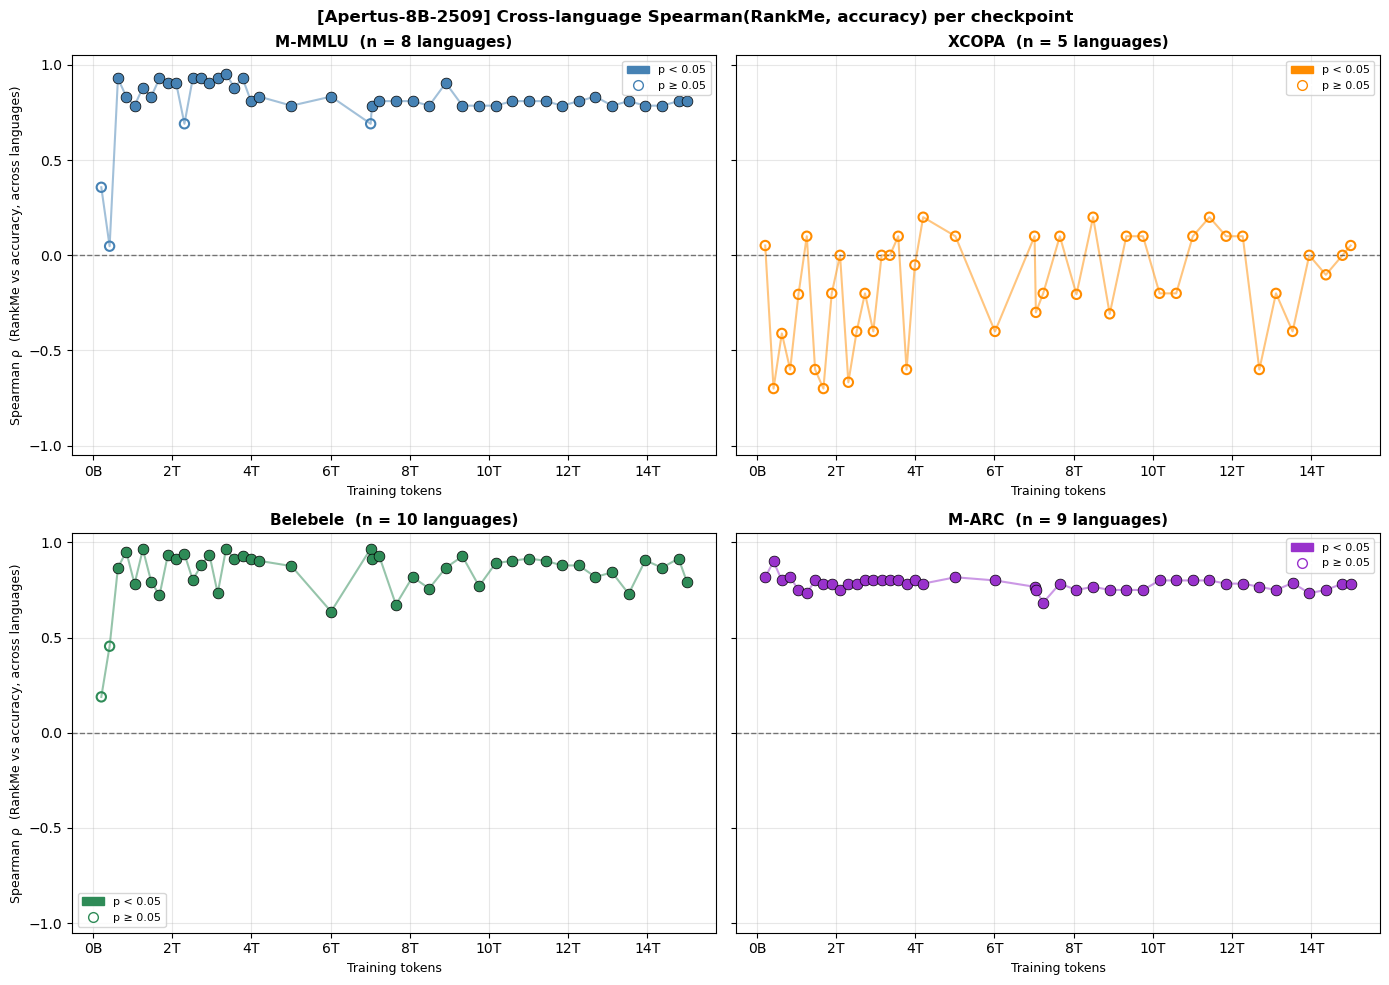

Saved: plots/rankme_checkpoint_correlations_apertus.png


In [15]:
show_checkpoint_correlations(MODELS, data)

## Per-Checkpoint Correlation Findings

### FuxiTranyu-8B

**m-MMLU (8 languages): 3/57 checkpoints significant, max ρ = 0.762**

Near-zero correlation throughout training, as expected. All 8 languages stay at random chance (~25%), leaving essentially no accuracy variance to correlate with RankMe. The 3 significant checkpoints are noise.

**XCOPA (5 languages): 1/57 checkpoints significant, min ρ = −0.900**

The minimum ρ = −0.900 at 147B tokens (the only significant checkpoint, p = 0.037) is the key result: the cross-language RankMe ranking is strongly *inversely* correlated with XCOPA accuracy at that point in training. This inversion is driven by language-level differences established early: Vietnamese has the lowest layer-15 RankMe at the first checkpoint (54.5), yet achieves the best peak XCOPA accuracy (0.736) and earliest grokking onset (126B); Chinese has one of the highest first-checkpoint RankMes and worse peak XCOPA accuracy. The geometry runs in the **opposite direction** to every other benchmark — consistent with the initial drop rate showing the opposite sign for XCOPA (Sp r = −0.900) relative to all other benchmarks (positive for M-ARC in both models), as explained in the predictor analysis section above.

**Belebele (10 languages): 5/57 checkpoints significant, max ρ = 0.869**

With all 10 languages near random chance (peak accuracy range 0.296–0.317), cross-language accuracy variance is negligible. The few significant checkpoints are isolated and do not reflect a sustained pattern. The geometry has no reliable predictive power for Belebele in FuxiTranyu-8B.

**M-ARC (9 languages): 18/57 checkpoints significant, max ρ = 0.803**

The strongest per-checkpoint result for FuxiTranyu-8B: 18 significant checkpoints, peaking at ρ = 0.803 at 436B tokens. Unlike every other Fuxi benchmark, M-ARC shows geometry with predictive power in both the current per-checkpoint analysis (RankMe ranking tracks accuracy ranking at each checkpoint) and the static predictor analysis above (initial drop rate predicts peak accuracy).

---

### Apertus-8B-2509

**m-MMLU (8 languages): 40/44 checkpoints significant, max ρ = 0.952**

Throughout 91% of training, the language ranking by RankMe at layer 21 is significantly correlated with the language ranking by m-MMLU accuracy at that same checkpoint (max ρ = 0.952). The geometry is thus predictive not only retrospectively from the final trajectory — as shown in the predictor analysis above — but also at each individual checkpoint throughout training.

**XCOPA (5 languages): 0/44 checkpoints significant, max ρ = 0.200**

No significant correlation at any checkpoint. XCOPA peak accuracies are tightly clustered (0.702–0.784) and established early — 3 of 5 languages grokk by 210B tokens — with accuracy remaining stable thereafter. Since cross-language accuracy variance stays low and flat throughout most of training, there is no signal for the per-checkpoint correlation to detect. This is consistent with the predictor analysis, where no static predictor reached significance for XCOPA in Apertus.

**Belebele (10 languages): 42/44 checkpoints significant, max ρ = 0.967**

The highest peak per-checkpoint correlation in the notebook: 95% of checkpoints reach significance, maximum ρ = 0.967. With 10 languages spanning a wide peak accuracy range (0.661–0.841), there is rich cross-language signal once languages start differentiating. The 2 non-significant checkpoints are the very earliest (210B and 420B), before any language has crossed the grokking threshold (all languages grokk between 630B and 2 100B).

**M-ARC (9 languages): 44/44 checkpoints significant, max ρ = 0.900**

The most consistent result in the notebook: every single checkpoint reaches significance (100%). Even at the very first checkpoint (210B), when only English has grokked and the remaining 7 languages (Hindi never grokks) are still below the threshold, the RankMe ranking already predicts the M-ARC accuracy ordering. The maximum ρ = 0.900 is slightly below Belebele's peak, but the perfect consistency across all checkpoints is unique to M-ARC.

---

### Cross-model summary

**M-ARC is the only benchmark where the per-checkpoint geometry is predictive in both models** — 18/57 significant checkpoints for FuxiTranyu-8B and 44/44 for Apertus-8B-2509. This replicates the cross-model finding from the predictor analysis, where the initial drop rate was the only static predictor that reached significance for M-ARC in both Fuxi and Apertus. For all other benchmarks, the per-checkpoint signal either does not exist in Fuxi (m-MMLU, Belebele) or runs in the opposite direction (XCOPA).

---

### 💡 Key findings

- **Both models — M-ARC:** the only benchmark with significant per-checkpoint geometry–accuracy correlation in both models, though to very different degrees. Replicates the cross-model pattern from the predictor analysis.
- **Apertus — m-MMLU and Belebele:** RankMe at layer 21 tracks the cross-language accuracy ranking throughout 91% and 95% of training respectively, the geometry predicts which languages perform best at each individual checkpoint, not only from the final trajectory.
- **Both models — XCOPA:** no significant per-checkpoint correlation.
- **Fuxi — m-MMLU and Belebele:** no per-checkpoint signal, accuracy stays near random chance throughout training, leaving no cross-language variance to detect.